# GPU-Accelerated 2D/3D Vascular Registration Benchmark

## Overview
This notebook implements a GPU-accelerated version of the MIP-based registration pipeline for evaluating robustness under:
- **Q1**: Noise degradation (Gaussian noise)
- **Q2**: Vessel volume loss (stroke simulation)
- **Q3**: Vessel group occlusion (proximal/medium/distal)

## Key Improvements over CPU Version
1. **PyTorch GPU acceleration** for volume transformations and projections
2. **Analytical gradients** via autograd (no finite differences)
3. **Batched operations** where possible
4. **Proper statistical testing** with bootstrap confidence intervals

## Requirements
- GPU runtime (T4, V100, or A100 recommended)
- PyTorch with CUDA support
- scipy, pandas, nibabel for data handling

In [ ]:
# Install dependencies if needed
# !pip install torch torchvision nibabel scipy pandas matplotlib seaborn tqdm

In [ ]:
# Mount Google Drive (for Colab)
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
print('Drive mounted.')

Mounted at /content/drive
Drive mounted.


In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import nibabel as nib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
GPU: Tesla T4
Memory: 15.6 GB


---
## 1. GPU-Accelerated Core Functions

In [ ]:
# =============================================================================
# GPU-Accelerated Rigid Transformation and Projection
# =============================================================================

def euler_to_rotation_matrix(rx: torch.Tensor, ry: torch.Tensor, rz: torch.Tensor) -> torch.Tensor:
    """
    Convert Euler angles (in degrees) to a 3x3 rotation matrix.
    Uses ZYX convention (same as scipy.ndimage.rotate sequence).
    """
    # Convert to radians
    rx_rad = rx * (torch.pi / 180.0)
    ry_rad = ry * (torch.pi / 180.0)
    rz_rad = rz * (torch.pi / 180.0)

    # Rotation matrices
    cos_x, sin_x = torch.cos(rx_rad), torch.sin(rx_rad)
    cos_y, sin_y = torch.cos(ry_rad), torch.sin(ry_rad)
    cos_z, sin_z = torch.cos(rz_rad), torch.sin(rz_rad)

    # Rx
    Rx = torch.stack([
        torch.stack([torch.ones_like(rx_rad), torch.zeros_like(rx_rad), torch.zeros_like(rx_rad)]),
        torch.stack([torch.zeros_like(rx_rad), cos_x, -sin_x]),
        torch.stack([torch.zeros_like(rx_rad), sin_x, cos_x])
    ])

    # Ry
    Ry = torch.stack([
        torch.stack([cos_y, torch.zeros_like(ry_rad), sin_y]),
        torch.stack([torch.zeros_like(ry_rad), torch.ones_like(ry_rad), torch.zeros_like(ry_rad)]),
        torch.stack([-sin_y, torch.zeros_like(ry_rad), cos_y])
    ])

    # Rz
    Rz = torch.stack([
        torch.stack([cos_z, -sin_z, torch.zeros_like(rz_rad)]),
        torch.stack([sin_z, cos_z, torch.zeros_like(rz_rad)]),
        torch.stack([torch.zeros_like(rz_rad), torch.zeros_like(rz_rad), torch.ones_like(rz_rad)])
    ])

    # Combined rotation: R = Rz @ Ry @ Rx
    R = torch.matmul(Rz, torch.matmul(Ry, Rx))
    return R


def build_affine_matrix_3d(
    rx_deg: torch.Tensor,
    ry_deg: torch.Tensor,
    rz_deg: torch.Tensor,
    tx: torch.Tensor,
    ty: torch.Tensor,
    tz: torch.Tensor,
    volume_shape: Tuple[int, int, int],
    spacing: Tuple[float, float, float] = (1.0, 1.0, 1.0)
) -> torch.Tensor:
    """
    Build a 3x4 affine matrix for grid_sample.
    Translation is in mm, converted to normalized coordinates.
    """
    D, H, W = volume_shape

    # Get rotation matrix
    R = euler_to_rotation_matrix(rx_deg, ry_deg, rz_deg)

    # Convert translation from mm to normalized coordinates [-1, 1]
    # grid_sample uses normalized coords where -1 and 1 are the edges
    tx_norm = tx / (spacing[0] * W / 2)
    ty_norm = ty / (spacing[1] * H / 2)
    tz_norm = tz / (spacing[2] * D / 2)

    # Build 3x4 affine matrix [R | t]
    t = torch.stack([tx_norm, ty_norm, tz_norm]).unsqueeze(1)
    affine = torch.cat([R, t], dim=1)

    return affine.unsqueeze(0)  # Add batch dimension


class DifferentiableProjector(torch.nn.Module):
    """
    GPU-accelerated differentiable MIP (Maximum/Sum Intensity Projection).
    Uses grid_sample for differentiable volume transformation.
    """

    def __init__(
        self,
        volume: torch.Tensor,
        spacing: Tuple[float, float, float] = (1.0, 1.0, 1.0),
        proj_axis: int = 0,
        blur_sigma: float = 1.0
    ):
        super().__init__()
        # Store volume as buffer (not parameter)
        self.register_buffer('volume', volume.unsqueeze(0).unsqueeze(0))  # [1, 1, D, H, W]
        self.spacing = spacing
        self.proj_axis = proj_axis
        self.blur_sigma = blur_sigma
        self.volume_shape = volume.shape

        # Pre-compute Gaussian kernel for blurring
        if blur_sigma > 0:
            self.blur_kernel = self._make_gaussian_kernel_3d(blur_sigma)
        else:
            self.blur_kernel = None

    def _make_gaussian_kernel_3d(self, sigma: float, kernel_size: int = None) -> torch.Tensor:
        """Create a 3D Gaussian kernel."""
        if kernel_size is None:
            kernel_size = int(4 * sigma + 1)
            if kernel_size % 2 == 0:
                kernel_size += 1

        x = torch.arange(kernel_size, dtype=torch.float32) - kernel_size // 2
        gauss_1d = torch.exp(-x**2 / (2 * sigma**2))
        gauss_1d = gauss_1d / gauss_1d.sum()

        # Create 3D kernel via outer products
        gauss_3d = gauss_1d.view(-1, 1, 1) * gauss_1d.view(1, -1, 1) * gauss_1d.view(1, 1, -1)
        return gauss_3d.view(1, 1, kernel_size, kernel_size, kernel_size)

    def transform_volume(self, pose_params: torch.Tensor) -> torch.Tensor:
        """
        Apply rigid transformation to the volume.
        pose_params: [rx, ry, rz, tx, ty, tz] in degrees and mm
        """
        rx, ry, rz, tx, ty, tz = pose_params

        # Build affine matrix
        affine = build_affine_matrix_3d(
            rx, ry, rz, tx, ty, tz,
            self.volume_shape,
            self.spacing
        ).to(self.volume.device)

        # Create sampling grid
        grid = F.affine_grid(
            affine,
            self.volume.shape,
            align_corners=True
        )

        # Sample transformed volume
        transformed = F.grid_sample(
            self.volume,
            grid,
            mode='bilinear',
            padding_mode='zeros',
            align_corners=True
        )

        return transformed

    def forward(self, pose_params: torch.Tensor) -> torch.Tensor:
        """
        Render a 2D projection at the given pose.
        Returns normalized projection image.
        """
        # Transform volume
        transformed = self.transform_volume(pose_params)

        # Apply Gaussian blur if specified
        if self.blur_kernel is not None:
            kernel = self.blur_kernel.to(transformed.device)
            pad = kernel.shape[-1] // 2
            transformed = F.conv3d(transformed, kernel, padding=pad)

        # Project (sum along axis)
        # volume shape: [1, 1, D, H, W]
        # proj_axis: 0=D (axial), 1=H (coronal), 2=W (sagittal)
        proj = transformed.sum(dim=self.proj_axis + 2)  # +2 for batch and channel dims
        proj = proj.squeeze(0).squeeze(0)  # Remove batch and channel

        # Normalize to [0, 1]
        pmin, pmax = proj.min(), proj.max()
        if pmax - pmin > 1e-8:
            proj = (proj - pmin) / (pmax - pmin)
        else:
            proj = torch.zeros_like(proj)

        return proj


print("GPU-accelerated projector defined.")

GPU-accelerated projector defined.


In [ ]:
# =============================================================================
# GPU-Accelerated Similarity Metrics
# =============================================================================

def ncc_torch(pred: torch.Tensor, target: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """
    Normalized Cross-Correlation (differentiable, GPU).
    Returns a scalar tensor.
    """
    pred_flat = pred.flatten()
    target_flat = target.flatten()

    pred_centered = pred_flat - pred_flat.mean()
    target_centered = target_flat - target_flat.mean()

    numer = (pred_centered * target_centered).sum()
    denom = torch.sqrt((pred_centered**2).sum() * (target_centered**2).sum()) + eps

    return numer / denom


def local_ncc_torch(
    pred: torch.Tensor,
    target: torch.Tensor,
    patch_size: int = 13,
    eps: float = 1e-8
) -> torch.Tensor:
    """
    Local Normalized Cross-Correlation computed over patches.
    """
    # Add batch and channel dims: [1, 1, H, W]
    pred = pred.unsqueeze(0).unsqueeze(0)
    target = target.unsqueeze(0).unsqueeze(0)

    # Use unfold to extract patches
    pad = patch_size // 2
    pred_padded = F.pad(pred, (pad, pad, pad, pad), mode='reflect')
    target_padded = F.pad(target, (pad, pad, pad, pad), mode='reflect')

    # Compute local means using average pooling
    kernel = torch.ones(1, 1, patch_size, patch_size, device=pred.device) / (patch_size**2)
    pred_mean = F.conv2d(pred_padded, kernel, padding=0)
    target_mean = F.conv2d(target_padded, kernel, padding=0)

    # Local variance and covariance
    pred_sq_mean = F.conv2d(pred_padded**2, kernel, padding=0)
    target_sq_mean = F.conv2d(target_padded**2, kernel, padding=0)
    pred_target_mean = F.conv2d(pred_padded * target_padded, kernel, padding=0)

    pred_var = pred_sq_mean - pred_mean**2
    target_var = target_sq_mean - target_mean**2
    covar = pred_target_mean - pred_mean * target_mean

    # NCC per patch
    ncc_map = covar / (torch.sqrt(pred_var * target_var) + eps)

    return ncc_map.mean()


def multiscale_ncc_torch(
    pred: torch.Tensor,
    target: torch.Tensor,
    patch_sizes: List[int] = [13, 65, 256],
    weights: List[float] = None
) -> torch.Tensor:
    """
    Multiscale NCC: average of local NCC at different patch sizes.
    Includes global NCC when patch_size equals image size.
    """
    if weights is None:
        weights = [1.0] * len(patch_sizes)

    total = 0.0
    weight_sum = 0.0

    for ps, w in zip(patch_sizes, weights):
        if ps >= min(pred.shape):
            # Global NCC
            ncc = ncc_torch(pred, target)
        else:
            ncc = local_ncc_torch(pred, target, patch_size=ps)
        total += w * ncc
        weight_sum += w

    return total / weight_sum


print("Similarity metrics defined.")

Similarity metrics defined.


In [ ]:
# =============================================================================
# GPU-Accelerated Registration Optimizer
# =============================================================================

@dataclass
class RegistrationConfig:
    """Configuration for registration optimization."""
    n_iters: int = 150
    lr_rot: float = 0.5
    lr_trans: float = 1.0
    metric: str = 'ncc'  # 'ncc', 'local_ncc', 'multiscale_ncc'
    convergence_threshold: float = 0.999
    patience: int = 20
    verbose: bool = True


@dataclass
class RegistrationResult:
    """Results from registration."""
    pred_pose: np.ndarray
    pred_image: np.ndarray
    best_score: float
    score_history: List[float]
    converged: bool
    n_iters_actual: int


def register_gpu(
    projector: DifferentiableProjector,
    target_image: torch.Tensor,
    init_pose: Optional[np.ndarray] = None,
    config: RegistrationConfig = None
) -> RegistrationResult:
    """
    GPU-accelerated registration using analytical gradients.

    Args:
        projector: DifferentiableProjector with the moving volume
        target_image: Target 2D image to register to
        init_pose: Initial pose [rx, ry, rz, tx, ty, tz], default zeros
        config: Registration configuration

    Returns:
        RegistrationResult with predicted pose and metrics
    """
    if config is None:
        config = RegistrationConfig()

    if init_pose is None:
        init_pose = np.zeros(6, dtype=np.float32)

    # Initialize pose as learnable parameters
    pose_params = torch.tensor(init_pose, dtype=torch.float32, device=device, requires_grad=True)

    # Separate learning rates for rotation and translation
    optimizer = torch.optim.Adam([
        {'params': [pose_params], 'lr': config.lr_rot}
    ])

    # Learning rate scheduler
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

    # Target image on GPU
    target = target_image.to(device)

    # Select similarity metric
    if config.metric == 'ncc':
        similarity_fn = ncc_torch
    elif config.metric == 'local_ncc':
        similarity_fn = lambda p, t: local_ncc_torch(p, t, patch_size=13)
    elif config.metric == 'multiscale_ncc':
        similarity_fn = lambda p, t: multiscale_ncc_torch(p, t, patch_sizes=[13, 65])
    else:
        raise ValueError(f"Unknown metric: {config.metric}")

    # Optimization loop
    best_score = -float('inf')
    best_pose = pose_params.detach().cpu().numpy().copy()
    score_history = []
    no_improve_count = 0
    converged = False

    iterator = range(config.n_iters)
    if config.verbose:
        iterator = tqdm(iterator, desc="Registering")

    for i in iterator:
        optimizer.zero_grad()

        # Forward pass
        pred_image = projector(pose_params)

        # Compute similarity (we want to maximize, so negate for loss)
        similarity = similarity_fn(pred_image, target)
        loss = -similarity  # Minimize negative similarity = maximize similarity

        # Backward pass
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_([pose_params], max_norm=1.0)

        # Update
        optimizer.step()
        scheduler.step()

        # Track progress
        score = similarity.item()
        score_history.append(score)

        if score > best_score:
            best_score = score
            best_pose = pose_params.detach().cpu().numpy().copy()
            no_improve_count = 0
        else:
            no_improve_count += 1

        if config.verbose:
            iterator.set_postfix({'score': f'{score:.4f}', 'best': f'{best_score:.4f}'})

        # Early stopping
        if best_score >= config.convergence_threshold:
            converged = True
            break

        if no_improve_count >= config.patience:
            break

    # Final render at best pose
    with torch.no_grad():
        best_pose_tensor = torch.tensor(best_pose, dtype=torch.float32, device=device)
        pred_final = projector(best_pose_tensor).cpu().numpy()

    return RegistrationResult(
        pred_pose=best_pose,
        pred_image=pred_final,
        best_score=best_score,
        score_history=score_history,
        converged=converged,
        n_iters_actual=len(score_history)
    )


def multiscale_register_gpu(
    projector: DifferentiableProjector,
    target_image: torch.Tensor,
    init_pose: Optional[np.ndarray] = None,
    scales: List[float] = [0.25, 0.5, 1.0],
    iters_per_scale: List[int] = [50, 75, 100],
    verbose: bool = True
) -> RegistrationResult:
    """
    Coarse-to-fine multiscale registration.
    """
    current_pose = init_pose if init_pose is not None else np.zeros(6, dtype=np.float32)
    all_scores = []

    for scale, n_iters in zip(scales, iters_per_scale):
        if verbose:
            print(f"\nScale {scale:.2f}, {n_iters} iterations")

        # Downsample target if scale < 1
        if scale < 1.0:
            target_scaled = F.interpolate(
                target_image.unsqueeze(0).unsqueeze(0),
                scale_factor=scale,
                mode='bilinear',
                align_corners=True
            ).squeeze()
        else:
            target_scaled = target_image

        # TODO: Also downsample projector volume for true multiscale
        # For now, we just use the full resolution projector

        config = RegistrationConfig(
            n_iters=n_iters,
            lr_rot=0.5 / scale,  # Higher LR at coarse scales
            lr_trans=1.0 / scale,
            verbose=verbose
        )

        result = register_gpu(
            projector=projector,
            target_image=target_scaled,
            init_pose=current_pose,
            config=config
        )

        current_pose = result.pred_pose
        all_scores.extend(result.score_history)

    # Final result
    return RegistrationResult(
        pred_pose=current_pose,
        pred_image=result.pred_image,
        best_score=result.best_score,
        score_history=all_scores,
        converged=result.converged,
        n_iters_actual=len(all_scores)
    )


print("Registration optimizer defined.")

Registration optimizer defined.


---
## 2. Data Loading and Preprocessing

In [ ]:
# =============================================================================
# Paths and Label Mapping
# =============================================================================

BASE_PATH = Path('/content/drive/MyDrive/CSE291G')
CT_DIR = BASE_PATH / 'imagesTr_topbrain_ct'
LABEL_DIR = BASE_PATH / 'labelsTr_topbrain_ct'
OUTPUT_DIR = BASE_PATH / 'output' / 'gpu_benchmark'
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

# TopBrain label mapping
TOPBRAIN_LABELS = {
    0: 'background',
    1: 'BA', 2: 'R-P1P2', 3: 'L-P1P2', 4: 'R-ICA', 5: 'R-M1',
    6: 'L-ICA', 7: 'L-M1', 8: 'R-Pcom', 9: 'L-Pcom', 10: 'R-Acom',
    11: 'R-A1A2', 12: 'L-A1A2', 13: 'R-A3', 14: 'L-A3',
    15: '3rd-A2', 16: '3rd-A3', 17: 'R-M2', 18: 'R-M3',
    19: 'L-M2', 20: 'L-M3', 21: 'R-P3P4', 22: 'L-P3P4',
    23: 'R-VA', 24: 'L-VA', 25: 'R-SCA', 26: 'L-SCA',
    27: 'R-AICA', 28: 'L-AICA', 29: 'R-PICA', 30: 'L-PICA',
    31: 'R-OphA', 32: 'L-OphA', 33: 'R-OA', 34: 'L-OA',
    35: 'VoG', 36: 'StS', 37: 'ICVs', 38: 'R-BVR', 39: 'L-BVR', 40: 'SSS'
}

# Vessel groups for Q3
VESSEL_GROUPS = {
    'proximal': [1, 4, 6, 23, 24],           # BA, R/L-ICA, R/L-VA
    'medium': [2, 3, 5, 7, 11, 12],          # P1P2, M1, A1A2
    'distal': [13, 14, 17, 18, 19, 20, 21, 22]  # A3, M2, M3, P3P4
}

print(f"Data paths configured.")
print(f"CT directory: {CT_DIR}")
print(f"Label directory: {LABEL_DIR}")

Data paths configured.
CT directory: /content/drive/MyDrive/CSE291G/imagesTr_topbrain_ct
Label directory: /content/drive/MyDrive/CSE291G/labelsTr_topbrain_ct


In [ ]:
# =============================================================================
# Data Loading Functions
# =============================================================================

def load_patient_data(patient_id: str, downsample_factor: int = 2) -> Dict:
    """
    Load CT and label data for a single patient.

    Args:
        patient_id: e.g., '001', '002'
        downsample_factor: Factor to reduce volume size (2 = half resolution)

    Returns:
        Dictionary with CT, labels, spacing, etc.
    """
    ct_path = CT_DIR / f'topcow_ct_{patient_id}_0000.nii.gz'
    label_path = LABEL_DIR / f'topcow_ct_{patient_id}.nii.gz'

    if not ct_path.exists():
        # Try without .gz
        ct_path = CT_DIR / f'topcow_ct_{patient_id}_0000.nii'
    if not label_path.exists():
        label_path = LABEL_DIR / f'topcow_ct_{patient_id}.nii'

    # Load NIfTI
    ct_img = nib.load(str(ct_path))
    label_img = nib.load(str(label_path))

    ct = ct_img.get_fdata().astype(np.float32)
    labels = label_img.get_fdata().astype(np.int16)

    # Get spacing
    spacing = ct_img.header.get_zooms()[:3]

    # Downsample if requested
    if downsample_factor > 1:
        from scipy.ndimage import zoom as scipy_zoom
        factor = 1.0 / downsample_factor
        ct = scipy_zoom(ct, factor, order=1)
        labels = scipy_zoom(labels, factor, order=0)  # Nearest for labels
        spacing = tuple(s * downsample_factor for s in spacing)

    return {
        'patient_id': patient_id,
        'ct': ct,
        'labels': labels,
        'spacing': spacing,
        'shape': ct.shape,
    }


def get_healthy_hemisphere(labels: np.ndarray, axis: int = 0) -> np.ndarray:
    """
    Extract the hemisphere with more vessel voxels (assumed healthy).
    """
    mid = labels.shape[axis] // 2

    if axis == 0:
        left_count = (labels[:mid] > 0).sum()
        right_count = (labels[mid:] > 0).sum()
    else:
        raise NotImplementedError("Only axis=0 supported")

    # Keep the hemisphere with more vessels
    healthy = labels.copy()
    if left_count >= right_count:
        healthy[mid:] = 0
    else:
        healthy[:mid] = 0

    return healthy


def create_binary_mask(labels: np.ndarray) -> np.ndarray:
    """Convert multi-class labels to binary vessel mask."""
    return (labels > 0).astype(np.float32)


print("Data loading functions defined.")

Data loading functions defined.


In [ ]:
# =============================================================================
# Perturbation Functions (Q1, Q2, Q3)
# =============================================================================

def add_gaussian_noise(image: np.ndarray, sigma: float, seed: int = None) -> np.ndarray:
    """Add Gaussian noise to a 2D image."""
    if seed is not None:
        np.random.seed(seed)
    noise = np.random.normal(0, sigma, image.shape).astype(np.float32)
    noisy = image + noise
    return np.clip(noisy, 0, 1)


def remove_random_vessel_volume(mask: np.ndarray, fraction: float, seed: int = None) -> np.ndarray:
    """Remove a random fraction of vessel voxels (Q2 - stroke simulation)."""
    if seed is not None:
        np.random.seed(seed)

    if fraction <= 0:
        return mask.copy()
    if fraction >= 1:
        return np.zeros_like(mask)

    result = mask.copy()
    vessel_indices = np.argwhere(mask > 0)
    n_remove = int(len(vessel_indices) * fraction)

    if n_remove > 0:
        remove_idx = np.random.choice(len(vessel_indices), n_remove, replace=False)
        for idx in remove_idx:
            i, j, k = vessel_indices[idx]
            result[i, j, k] = 0

    return result


def remove_vessel_group(labels: np.ndarray, group_ids: List[int]) -> np.ndarray:
    """Remove specific vessel groups (Q3 - anatomical occlusion)."""
    result = labels.copy()
    for gid in group_ids:
        result[result == gid] = 0
    return result


print("Perturbation functions defined.")

Perturbation functions defined.


---
## 3. Evaluation Metrics

In [ ]:
# =============================================================================
# Mean Target Registration Error (mTRE)
# =============================================================================

def sample_vessel_target_points(mask: np.ndarray, n_points: int = 200, seed: int = 42) -> np.ndarray:
    """
    Sample random points from the vessel mask for mTRE computation.
    Returns: [n_points, 3] array of (i, j, k) indices
    """
    np.random.seed(seed)
    vessel_indices = np.argwhere(mask > 0)

    if len(vessel_indices) < n_points:
        return vessel_indices

    idx = np.random.choice(len(vessel_indices), n_points, replace=False)
    return vessel_indices[idx]


def apply_pose_to_points(
    points: np.ndarray,
    pose: np.ndarray,
    spacing: Tuple[float, float, float],
    volume_center: np.ndarray
) -> np.ndarray:
    """
    Apply rigid transformation to a set of 3D points.

    Args:
        points: [N, 3] array of points in voxel coordinates
        pose: [rx, ry, rz, tx, ty, tz] in degrees and mm
        spacing: Voxel spacing in mm
        volume_center: Center of the volume for rotation

    Returns:
        Transformed points in mm
    """
    from scipy.spatial.transform import Rotation

    rx, ry, rz, tx, ty, tz = pose

    # Convert to physical coordinates (mm)
    points_mm = (points - volume_center) * np.array(spacing)

    # Apply rotation
    R = Rotation.from_euler('xyz', [rx, ry, rz], degrees=True)
    points_rotated = R.apply(points_mm)

    # Apply translation
    points_translated = points_rotated + np.array([tx, ty, tz])

    return points_translated


def compute_mTRE(
    pred_pose: np.ndarray,
    gt_pose: np.ndarray,
    target_points: np.ndarray,
    spacing: Tuple[float, float, float],
    volume_shape: Tuple[int, int, int]
) -> Dict[str, float]:
    """
    Compute mean Target Registration Error.

    Returns:
        Dictionary with mTRE, median TRE, max TRE, and success rate
    """
    volume_center = np.array(volume_shape) / 2.0

    # Transform points with both poses
    points_pred = apply_pose_to_points(target_points, pred_pose, spacing, volume_center)
    points_gt = apply_pose_to_points(target_points, gt_pose, spacing, volume_center)

    # Compute distances
    distances = np.linalg.norm(points_pred - points_gt, axis=1)

    return {
        'mTRE_mm': float(np.mean(distances)),
        'median_TRE_mm': float(np.median(distances)),
        'max_TRE_mm': float(np.max(distances)),
        'std_TRE_mm': float(np.std(distances)),
        'success_1mm': float(np.mean(distances) <= 1.0),
        'success_2mm': float(np.mean(distances) <= 2.0),
    }


def compute_pose_error(pred_pose: np.ndarray, gt_pose: np.ndarray) -> Dict[str, float]:
    """Compute rotation and translation errors."""
    diff = pred_pose - gt_pose
    return {
        'rot_err_deg': float(np.linalg.norm(diff[:3])),
        'trans_err_mm': float(np.linalg.norm(diff[3:])),
        'rx_err': float(diff[0]),
        'ry_err': float(diff[1]),
        'rz_err': float(diff[2]),
        'tx_err': float(diff[3]),
        'ty_err': float(diff[4]),
        'tz_err': float(diff[5]),
    }


print("Evaluation metrics defined.")

Evaluation metrics defined.


---
## 4. Benchmark Runner

In [ ]:
# =============================================================================
# Main Benchmark Class
# =============================================================================

@dataclass
class BenchmarkConfig:
    """Configuration for the full benchmark."""
    # Patients to process
    patient_ids: List[str] = field(default_factory=lambda: ['001', '002', '003'])

    # Downsampling for speed
    downsample_factor: int = 2

    # Ground truth pose (random perturbation from identity)
    gt_pose_seed: int = 42
    gt_rot_range: float = 5.0  # degrees
    gt_trans_range: float = 5.0  # mm

    # Q1: Noise levels
    noise_sigmas: List[float] = field(default_factory=lambda: [0.0, 0.01, 0.03, 0.05, 0.10])

    # Q2: Volume loss fractions
    volume_loss_fractions: List[float] = field(default_factory=lambda: [0.0, 0.10, 0.25, 0.50, 1.0])

    # Q3: Vessel groups
    vessel_groups: Dict[str, List[int]] = field(default_factory=lambda: VESSEL_GROUPS)

    # Registration config
    reg_n_iters: int = 100
    reg_metric: str = 'ncc'

    # Number of random trials per condition (for statistics)
    n_trials_per_condition: int = 5


class VascularBenchmark:
    """
    Main benchmark runner for vascular registration experiments.
    """

    def __init__(self, config: BenchmarkConfig):
        self.config = config
        self.results = []

    def generate_gt_pose(self, seed: int) -> np.ndarray:
        """Generate a random ground truth pose."""
        np.random.seed(seed)
        rot = np.random.uniform(-self.config.gt_rot_range, self.config.gt_rot_range, 3)
        trans = np.random.uniform(-self.config.gt_trans_range, self.config.gt_trans_range, 3)
        return np.concatenate([rot, trans]).astype(np.float32)

    def run_single_registration(
        self,
        projector: DifferentiableProjector,
        target_image: torch.Tensor,
        gt_pose: np.ndarray,
        target_points: np.ndarray,
        spacing: Tuple[float, float, float],
        volume_shape: Tuple[int, int, int]
    ) -> Dict:
        """Run a single registration and compute metrics."""
        config = RegistrationConfig(
            n_iters=self.config.reg_n_iters,
            metric=self.config.reg_metric,
            verbose=False
        )

        result = register_gpu(
            projector=projector,
            target_image=target_image,
            init_pose=None,  # Start from identity
            config=config
        )

        # Compute errors
        mtre = compute_mTRE(result.pred_pose, gt_pose, target_points, spacing, volume_shape)
        pose_err = compute_pose_error(result.pred_pose, gt_pose)

        return {
            **mtre,
            **pose_err,
            'best_ncc': result.best_score,
            'converged': result.converged,
            'n_iters': result.n_iters_actual,
        }

    def run_q1_benchmark(self, patient_data: Dict, verbose: bool = True) -> pd.DataFrame:
        """
        Q1: Noise degradation benchmark.
        """
        if verbose:
            print(f"\n=== Q1: Noise Degradation (Patient {patient_data['patient_id']}) ===")

        # Prepare data
        healthy_labels = get_healthy_hemisphere(patient_data['labels'])
        binary_mask = create_binary_mask(healthy_labels)
        spacing = patient_data['spacing']
        shape = patient_data['shape']

        # Create projector
        volume_tensor = torch.tensor(binary_mask, dtype=torch.float32, device=device)
        projector = DifferentiableProjector(volume_tensor, spacing=spacing, proj_axis=0)

        # Sample target points for mTRE
        target_points = sample_vessel_target_points(binary_mask, n_points=200)

        rows = []

        for trial in range(self.config.n_trials_per_condition):
            # Generate GT pose for this trial
            gt_pose = self.generate_gt_pose(self.config.gt_pose_seed + trial)

            # Render baseline DSA at GT pose
            with torch.no_grad():
                gt_pose_tensor = torch.tensor(gt_pose, dtype=torch.float32, device=device)
                baseline_dsa = projector(gt_pose_tensor).cpu().numpy()

            for sigma in self.config.noise_sigmas:
                # Add noise
                noisy_dsa = add_gaussian_noise(baseline_dsa, sigma, seed=trial * 100 + int(sigma * 1000))
                target_image = torch.tensor(noisy_dsa, dtype=torch.float32, device=device)

                # Run registration
                metrics = self.run_single_registration(
                    projector, target_image, gt_pose, target_points, spacing, shape
                )

                rows.append({
                    'patient_id': patient_data['patient_id'],
                    'question': 'Q1',
                    'condition': f'sigma_{sigma}',
                    'noise_sigma': sigma,
                    'trial': trial,
                    **metrics
                })

                if verbose:
                    print(f"  Trial {trial}, σ={sigma:.2f}: mTRE={metrics['mTRE_mm']:.2f}mm, NCC={metrics['best_ncc']:.3f}")

        return pd.DataFrame(rows)

    def run_q2_benchmark(self, patient_data: Dict, verbose: bool = True) -> pd.DataFrame:
        """
        Q2: Vessel volume loss benchmark.
        """
        if verbose:
            print(f"\n=== Q2: Volume Loss (Patient {patient_data['patient_id']}) ===")

        healthy_labels = get_healthy_hemisphere(patient_data['labels'])
        binary_mask = create_binary_mask(healthy_labels)
        spacing = patient_data['spacing']
        shape = patient_data['shape']

        # Create projector with FULL anatomy (for rendering moving volume)
        volume_tensor = torch.tensor(binary_mask, dtype=torch.float32, device=device)
        projector = DifferentiableProjector(volume_tensor, spacing=spacing, proj_axis=0)

        target_points = sample_vessel_target_points(binary_mask, n_points=200)

        rows = []

        for trial in range(self.config.n_trials_per_condition):
            gt_pose = self.generate_gt_pose(self.config.gt_pose_seed + trial)

            for frac in self.config.volume_loss_fractions:
                # Create degraded mask
                degraded_mask = remove_random_vessel_volume(
                    binary_mask, frac, seed=trial * 100 + int(frac * 1000)
                )

                # Create target DSA from degraded anatomy
                degraded_tensor = torch.tensor(degraded_mask, dtype=torch.float32, device=device)
                degraded_projector = DifferentiableProjector(degraded_tensor, spacing=spacing, proj_axis=0)

                with torch.no_grad():
                    gt_pose_tensor = torch.tensor(gt_pose, dtype=torch.float32, device=device)
                    target_dsa = degraded_projector(gt_pose_tensor).cpu().numpy()

                target_image = torch.tensor(target_dsa, dtype=torch.float32, device=device)

                # Run registration (using full anatomy projector)
                metrics = self.run_single_registration(
                    projector, target_image, gt_pose, target_points, spacing, shape
                )

                rows.append({
                    'patient_id': patient_data['patient_id'],
                    'question': 'Q2',
                    'condition': f'loss_{int(frac*100):03d}',
                    'volume_loss_frac': frac,
                    'trial': trial,
                    **metrics
                })

                if verbose:
                    print(f"  Trial {trial}, loss={frac:.0%}: mTRE={metrics['mTRE_mm']:.2f}mm")

        return pd.DataFrame(rows)

    def run_q3_benchmark(self, patient_data: Dict, verbose: bool = True) -> pd.DataFrame:
        """
        Q3: Vessel group occlusion benchmark.
        """
        if verbose:
            print(f"\n=== Q3: Vessel Group Occlusion (Patient {patient_data['patient_id']}) ===")

        healthy_labels = get_healthy_hemisphere(patient_data['labels'])
        binary_mask = create_binary_mask(healthy_labels)
        spacing = patient_data['spacing']
        shape = patient_data['shape']

        # Full anatomy projector
        volume_tensor = torch.tensor(binary_mask, dtype=torch.float32, device=device)
        projector = DifferentiableProjector(volume_tensor, spacing=spacing, proj_axis=0)

        target_points = sample_vessel_target_points(binary_mask, n_points=200)

        rows = []

        # Include baseline (no occlusion)
        conditions = {'baseline': []}
        conditions.update(self.config.vessel_groups)

        for trial in range(self.config.n_trials_per_condition):
            gt_pose = self.generate_gt_pose(self.config.gt_pose_seed + trial)

            for group_name, group_ids in conditions.items():
                # Create occluded labels
                if group_ids:
                    occluded_labels = remove_vessel_group(healthy_labels, group_ids)
                else:
                    occluded_labels = healthy_labels

                occluded_mask = create_binary_mask(occluded_labels)

                # Create target DSA
                occluded_tensor = torch.tensor(occluded_mask, dtype=torch.float32, device=device)
                occluded_projector = DifferentiableProjector(occluded_tensor, spacing=spacing, proj_axis=0)

                with torch.no_grad():
                    gt_pose_tensor = torch.tensor(gt_pose, dtype=torch.float32, device=device)
                    target_dsa = occluded_projector(gt_pose_tensor).cpu().numpy()

                target_image = torch.tensor(target_dsa, dtype=torch.float32, device=device)

                # Run registration
                metrics = self.run_single_registration(
                    projector, target_image, gt_pose, target_points, spacing, shape
                )

                rows.append({
                    'patient_id': patient_data['patient_id'],
                    'question': 'Q3',
                    'condition': group_name,
                    'vessel_group': group_name,
                    'trial': trial,
                    **metrics
                })

                if verbose:
                    print(f"  Trial {trial}, {group_name}: mTRE={metrics['mTRE_mm']:.2f}mm")

        return pd.DataFrame(rows)

    def run_full_benchmark(self, verbose: bool = True) -> pd.DataFrame:
        """
        Run the complete benchmark across all patients and questions.
        """
        all_results = []

        for pid in tqdm(self.config.patient_ids, desc="Patients"):
            print(f"\n{'='*60}")
            print(f"Processing Patient {pid}")
            print('='*60)

            try:
                patient_data = load_patient_data(pid, self.config.downsample_factor)
                print(f"Loaded: shape={patient_data['shape']}, spacing={patient_data['spacing']}")

                # Run Q1, Q2, Q3
                q1_df = self.run_q1_benchmark(patient_data, verbose)
                q2_df = self.run_q2_benchmark(patient_data, verbose)
                q3_df = self.run_q3_benchmark(patient_data, verbose)

                all_results.extend([q1_df, q2_df, q3_df])

                # Clear GPU memory
                torch.cuda.empty_cache()

            except Exception as e:
                print(f"ERROR processing patient {pid}: {e}")
                continue

        return pd.concat(all_results, ignore_index=True)


print("Benchmark class defined.")

Benchmark class defined.


---
## 5. Statistical Analysis

In [ ]:
# =============================================================================
# Statistical Testing Functions
# =============================================================================

from scipy import stats

def bootstrap_ci(
    data: np.ndarray,
    statistic: callable = np.mean,
    n_bootstrap: int = 1000,
    ci: float = 0.95,
    seed: int = 42
) -> Tuple[float, float, float]:
    """
    Compute bootstrap confidence interval.

    Returns:
        (point_estimate, ci_lower, ci_upper)
    """
    np.random.seed(seed)
    n = len(data)

    # Bootstrap samples
    boot_stats = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=n, replace=True)
        boot_stats.append(statistic(sample))

    boot_stats = np.array(boot_stats)

    # Confidence interval
    alpha = 1 - ci
    ci_lower = np.percentile(boot_stats, 100 * alpha / 2)
    ci_upper = np.percentile(boot_stats, 100 * (1 - alpha / 2))

    return statistic(data), ci_lower, ci_upper


def wilcoxon_paired_test(
    baseline: np.ndarray,
    condition: np.ndarray,
    alternative: str = 'greater'
) -> Dict[str, float]:
    """
    Wilcoxon signed-rank test for paired samples.

    Args:
        baseline: mTRE values for baseline condition
        condition: mTRE values for test condition
        alternative: 'greater' (condition > baseline), 'less', or 'two-sided'

    Returns:
        Dictionary with statistic, p-value, and effect size
    """
    diff = condition - baseline

    # Wilcoxon test
    try:
        stat, pval = stats.wilcoxon(diff, alternative=alternative)
    except ValueError:
        # All differences are zero
        stat, pval = 0.0, 1.0

    # Effect size (rank-biserial correlation)
    n = len(diff)
    r = 1 - (2 * stat) / (n * (n + 1) / 2) if n > 0 else 0.0

    return {
        'statistic': float(stat),
        'p_value': float(pval),
        'effect_size_r': float(r),
        'median_diff': float(np.median(diff)),
        'mean_diff': float(np.mean(diff)),
    }


def friedman_test(groups: List[np.ndarray]) -> Dict[str, float]:
    """
    Friedman test for comparing multiple related groups.

    Args:
        groups: List of arrays, one per condition (must be same length)

    Returns:
        Dictionary with statistic and p-value
    """
    stat, pval = stats.friedmanchisquare(*groups)

    return {
        'statistic': float(stat),
        'p_value': float(pval),
        'n_groups': len(groups),
        'n_samples': len(groups[0]),
    }


def holm_bonferroni_correction(p_values: List[float], alpha: float = 0.05) -> List[Tuple[float, bool]]:
    """
    Apply Holm-Bonferroni correction for multiple comparisons.

    Returns:
        List of (adjusted_p, is_significant) tuples
    """
    n = len(p_values)
    sorted_idx = np.argsort(p_values)

    results = [None] * n

    for rank, idx in enumerate(sorted_idx):
        adjusted_alpha = alpha / (n - rank)
        is_sig = p_values[idx] < adjusted_alpha

        # Adjusted p-value (simplified)
        adj_p = min(p_values[idx] * (n - rank), 1.0)

        results[idx] = (adj_p, is_sig)

    return results


def non_inferiority_test(
    data: np.ndarray,
    margin: float = 1.0,
    ci: float = 0.95
) -> Dict[str, any]:
    """
    Non-inferiority test: Is the upper CI bound below the margin?

    Args:
        data: mTRE values
        margin: Non-inferiority margin (e.g., 1.0 mm)
        ci: Confidence level

    Returns:
        Dictionary with mean, CI, and non-inferiority result
    """
    mean, ci_lower, ci_upper = bootstrap_ci(data, np.mean, ci=ci)

    is_non_inferior = ci_upper < margin

    return {
        'mean': mean,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'margin': margin,
        'is_non_inferior': is_non_inferior,
    }


print("Statistical functions defined.")

Statistical functions defined.


In [ ]:
# =============================================================================
# Statistical Analysis for Each Question
# =============================================================================

class StatisticalAnalyzer:
    """
    Perform statistical analysis on benchmark results.
    """

    def __init__(self, results_df: pd.DataFrame):
        self.df = results_df

    def analyze_q1(self, alpha: float = 0.05) -> Dict:
        """
        Q1: To what extent of noise degradation can registration tolerate?

        Statistical approach:
        - Paired Wilcoxon tests: baseline (σ=0) vs each noise level
        - Holm-Bonferroni correction for multiple comparisons
        """
        q1_df = self.df[self.df['question'] == 'Q1'].copy()

        if q1_df.empty:
            return {'error': 'No Q1 data'}

        # Get unique noise levels
        noise_levels = sorted(q1_df['noise_sigma'].unique())
        baseline_sigma = noise_levels[0]  # Usually 0

        # Group by patient and trial for paired comparison
        results = {'comparisons': [], 'summary': {}}

        # Get baseline data
        baseline_data = q1_df[q1_df['noise_sigma'] == baseline_sigma]['mTRE_mm'].values

        p_values = []
        comparison_results = []

        for sigma in noise_levels[1:]:
            condition_data = q1_df[q1_df['noise_sigma'] == sigma]['mTRE_mm'].values

            # Paired test
            test_result = wilcoxon_paired_test(
                baseline_data[:len(condition_data)],
                condition_data,
                alternative='less'  # Is condition worse (higher mTRE)?
            )

            p_values.append(test_result['p_value'])
            comparison_results.append({
                'comparison': f'σ=0 vs σ={sigma}',
                **test_result
            })

        # Apply Holm-Bonferroni correction
        corrections = holm_bonferroni_correction(p_values, alpha)

        for i, (adj_p, is_sig) in enumerate(corrections):
            comparison_results[i]['p_adjusted'] = adj_p
            comparison_results[i]['significant'] = is_sig

        results['comparisons'] = comparison_results

        # Summary statistics per noise level
        summary = q1_df.groupby('noise_sigma')['mTRE_mm'].agg(['mean', 'std', 'median']).reset_index()
        results['summary'] = summary.to_dict('records')

        return results

    def analyze_q2(self, margin: float = 1.0) -> Dict:
        """
        Q2: How does vessel volume loss affect registration?

        Statistical approach:
        - Non-inferiority testing with margin = 1mm
        - Bootstrap 95% CI for each condition
        """
        q2_df = self.df[self.df['question'] == 'Q2'].copy()

        if q2_df.empty:
            return {'error': 'No Q2 data'}

        loss_fractions = sorted(q2_df['volume_loss_frac'].unique())

        results = {'non_inferiority': [], 'summary': {}}

        for frac in loss_fractions:
            data = q2_df[q2_df['volume_loss_frac'] == frac]['mTRE_mm'].values

            ni_result = non_inferiority_test(data, margin=margin)
            ni_result['volume_loss'] = frac
            results['non_inferiority'].append(ni_result)

        # Summary
        summary = q2_df.groupby('volume_loss_frac')['mTRE_mm'].agg(['mean', 'std', 'median']).reset_index()
        results['summary'] = summary.to_dict('records')

        return results

    def analyze_q3(self, alpha: float = 0.05) -> Dict:
        """
        Q3: How does vessel group occlusion affect registration?

        Statistical approach:
        - (i) Paired Wilcoxon tests: baseline vs each occlusion type
        - (ii) Friedman test: differences among occlusion types
        """
        q3_df = self.df[self.df['question'] == 'Q3'].copy()

        if q3_df.empty:
            return {'error': 'No Q3 data'}

        conditions = q3_df['vessel_group'].unique()

        results = {
            'baseline_comparisons': [],
            'friedman_test': None,
            'summary': {}
        }

        # (i) Baseline vs each occlusion
        baseline_data = q3_df[q3_df['vessel_group'] == 'baseline']['mTRE_mm'].values

        p_values = []
        comparison_results = []
        occlusion_groups = [c for c in conditions if c != 'baseline']

        for group in occlusion_groups:
            group_data = q3_df[q3_df['vessel_group'] == group]['mTRE_mm'].values

            min_len = min(len(baseline_data), len(group_data))
            test_result = wilcoxon_paired_test(
                baseline_data[:min_len],
                group_data[:min_len],
                alternative='less'
            )

            p_values.append(test_result['p_value'])
            comparison_results.append({
                'comparison': f'baseline vs {group}',
                **test_result
            })

        # Holm-Bonferroni correction
        if p_values:
            corrections = holm_bonferroni_correction(p_values, alpha)
            for i, (adj_p, is_sig) in enumerate(corrections):
                comparison_results[i]['p_adjusted'] = adj_p
                comparison_results[i]['significant'] = is_sig

        results['baseline_comparisons'] = comparison_results

        # (ii) Friedman test among occlusion types
        if len(occlusion_groups) >= 2:
            groups_data = []
            min_samples = float('inf')

            for group in occlusion_groups:
                data = q3_df[q3_df['vessel_group'] == group]['mTRE_mm'].values
                groups_data.append(data)
                min_samples = min(min_samples, len(data))

            # Truncate to same length
            groups_data = [g[:min_samples] for g in groups_data]

            if min_samples >= 3:
                results['friedman_test'] = friedman_test(groups_data)

        # Summary
        summary = q3_df.groupby('vessel_group')['mTRE_mm'].agg(['mean', 'std', 'median']).reset_index()
        results['summary'] = summary.to_dict('records')

        return results

    def generate_report(self) -> str:
        """
        Generate a text report of all statistical analyses.
        """
        report = []
        report.append("=" * 70)
        report.append("STATISTICAL ANALYSIS REPORT")
        report.append("=" * 70)

        # Q1
        report.append("\n" + "=" * 70)
        report.append("Q1: NOISE DEGRADATION TOLERANCE")
        report.append("=" * 70)
        q1_results = self.analyze_q1()

        if 'summary' in q1_results:
            report.append("\nSummary by noise level:")
            for row in q1_results['summary']:
                report.append(f"  σ={row['noise_sigma']:.2f}: mean={row['mean']:.2f}mm, "
                            f"std={row['std']:.2f}mm, median={row['median']:.2f}mm")

        if 'comparisons' in q1_results:
            report.append("\nPaired comparisons (Wilcoxon, Holm-Bonferroni corrected):")
            for comp in q1_results['comparisons']:
                sig_str = "*" if comp.get('significant', False) else ""
                report.append(f"  {comp['comparison']}: p={comp.get('p_adjusted', comp['p_value']):.4f}{sig_str}, "
                            f"median_diff={comp['median_diff']:.3f}mm")

        # Q2
        report.append("\n" + "=" * 70)
        report.append("Q2: VESSEL VOLUME LOSS")
        report.append("=" * 70)
        q2_results = self.analyze_q2()

        if 'non_inferiority' in q2_results:
            report.append("\nNon-inferiority testing (margin = 1.0mm):")
            for ni in q2_results['non_inferiority']:
                ni_str = "✓ NON-INFERIOR" if ni['is_non_inferior'] else "✗ NOT non-inferior"
                report.append(f"  Loss={ni['volume_loss']:.0%}: mean={ni['mean']:.2f}mm, "
                            f"95% CI=[{ni['ci_lower']:.2f}, {ni['ci_upper']:.2f}] → {ni_str}")

        # Q3
        report.append("\n" + "=" * 70)
        report.append("Q3: VESSEL GROUP OCCLUSION")
        report.append("=" * 70)
        q3_results = self.analyze_q3()

        if 'summary' in q3_results:
            report.append("\nSummary by occlusion type:")
            for row in q3_results['summary']:
                report.append(f"  {row['vessel_group']}: mean={row['mean']:.2f}mm, "
                            f"std={row['std']:.2f}mm")

        if 'baseline_comparisons' in q3_results:
            report.append("\n(i) Paired comparisons vs baseline:")
            for comp in q3_results['baseline_comparisons']:
                sig_str = "*" if comp.get('significant', False) else ""
                report.append(f"  {comp['comparison']}: p={comp.get('p_adjusted', comp['p_value']):.4f}{sig_str}")

        if q3_results.get('friedman_test'):
            ft = q3_results['friedman_test']
            sig_str = "*" if ft['p_value'] < 0.05 else ""
            report.append(f"\n(ii) Friedman test among occlusion types: χ²={ft['statistic']:.2f}, p={ft['p_value']:.4f}{sig_str}")

        report.append("\n" + "=" * 70)
        report.append("* indicates p < 0.05 after correction")
        report.append("=" * 70)

        return "\n".join(report)


print("Statistical analyzer defined.")

Statistical analyzer defined.


---
## 6. Visualization

In [ ]:
# =============================================================================
# Visualization Functions
# =============================================================================

def plot_q1_results(df: pd.DataFrame, output_path: Path = None):
    """Plot Q1 noise degradation results."""
    q1_df = df[df['question'] == 'Q1'].copy()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Line plot: mTRE vs noise
    ax = axes[0]
    summary = q1_df.groupby('noise_sigma')['mTRE_mm'].agg(['mean', 'std']).reset_index()
    ax.errorbar(summary['noise_sigma'], summary['mean'], yerr=summary['std'],
                marker='o', capsize=5, linewidth=2, markersize=8)
    ax.axhline(y=1.0, color='r', linestyle='--', label='1mm threshold')
    ax.set_xlabel('Noise σ', fontsize=12)
    ax.set_ylabel('mTRE (mm)', fontsize=12)
    ax.set_title('Q1: Registration Error vs Noise Level', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Box plot
    ax = axes[1]
    q1_df['noise_label'] = q1_df['noise_sigma'].apply(lambda x: f'σ={x}')
    sns.boxplot(data=q1_df, x='noise_label', y='mTRE_mm', ax=ax)
    ax.axhline(y=1.0, color='r', linestyle='--')
    ax.set_xlabel('Noise Level', fontsize=12)
    ax.set_ylabel('mTRE (mm)', fontsize=12)
    ax.set_title('Q1: mTRE Distribution by Noise Level', fontsize=14)

    plt.tight_layout()

    if output_path:
        plt.savefig(output_path / 'q1_noise_results.png', dpi=150, bbox_inches='tight')

    plt.show()


def plot_q2_results(df: pd.DataFrame, output_path: Path = None):
    """Plot Q2 volume loss results."""
    q2_df = df[df['question'] == 'Q2'].copy()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Bar chart with error bars
    ax = axes[0]
    summary = q2_df.groupby('volume_loss_frac')['mTRE_mm'].agg(['mean', 'std']).reset_index()
    x = np.arange(len(summary))
    bars = ax.bar(x, summary['mean'], yerr=summary['std'], capsize=5,
                  color='steelblue', alpha=0.7, edgecolor='black')
    ax.axhline(y=1.0, color='r', linestyle='--', label='1mm threshold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'{int(f*100)}%' for f in summary['volume_loss_frac']])
    ax.set_xlabel('Vessel Volume Loss', fontsize=12)
    ax.set_ylabel('mTRE (mm)', fontsize=12)
    ax.set_title('Q2: Registration Error vs Volume Loss', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

    # Box plot
    ax = axes[1]
    q2_df['loss_label'] = q2_df['volume_loss_frac'].apply(lambda x: f'{int(x*100)}%')
    sns.boxplot(data=q2_df, x='loss_label', y='mTRE_mm', ax=ax,
                order=['0%', '10%', '25%', '50%', '100%'])
    ax.axhline(y=1.0, color='r', linestyle='--')
    ax.set_xlabel('Volume Loss', fontsize=12)
    ax.set_ylabel('mTRE (mm)', fontsize=12)
    ax.set_title('Q2: mTRE Distribution by Volume Loss', fontsize=14)

    plt.tight_layout()

    if output_path:
        plt.savefig(output_path / 'q2_volume_loss_results.png', dpi=150, bbox_inches='tight')

    plt.show()


def plot_q3_results(df: pd.DataFrame, output_path: Path = None):
    """Plot Q3 vessel group occlusion results."""
    q3_df = df[df['question'] == 'Q3'].copy()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Grouped box plot
    ax = axes[0]
    order = ['baseline', 'proximal', 'medium', 'distal']
    available_order = [o for o in order if o in q3_df['vessel_group'].unique()]
    sns.boxplot(data=q3_df, x='vessel_group', y='mTRE_mm', ax=ax, order=available_order)
    ax.axhline(y=1.0, color='r', linestyle='--', label='1mm threshold')
    ax.set_xlabel('Occlusion Condition', fontsize=12)
    ax.set_ylabel('mTRE (mm)', fontsize=12)
    ax.set_title('Q3: mTRE by Vessel Group Occlusion', fontsize=14)
    ax.legend()

    # Bar chart with mean ± std
    ax = axes[1]
    summary = q3_df.groupby('vessel_group')['mTRE_mm'].agg(['mean', 'std']).reindex(available_order)
    x = np.arange(len(summary))
    colors = ['green', 'orange', 'blue', 'purple'][:len(summary)]
    bars = ax.bar(x, summary['mean'], yerr=summary['std'], capsize=5,
                  color=colors, alpha=0.7, edgecolor='black')
    ax.axhline(y=1.0, color='r', linestyle='--')
    ax.set_xticks(x)
    ax.set_xticklabels(summary.index)
    ax.set_xlabel('Occlusion Type', fontsize=12)
    ax.set_ylabel('mTRE (mm)', fontsize=12)
    ax.set_title('Q3: Mean Registration Error by Occlusion', fontsize=14)
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()

    if output_path:
        plt.savefig(output_path / 'q3_occlusion_results.png', dpi=150, bbox_inches='tight')

    plt.show()


def plot_all_results(df: pd.DataFrame, output_path: Path = None):
    """Generate all plots."""
    plot_q1_results(df, output_path)
    plot_q2_results(df, output_path)
    plot_q3_results(df, output_path)


print("Visualization functions defined.")

Visualization functions defined.


---
## 7. Run the Benchmark

In [ ]:
# =============================================================================
# Configure and Run Benchmark
# =============================================================================

# Configuration for fewer patients but more trials for statistics
config = BenchmarkConfig(
    # Use 3 patients (adjust based on available data)
    patient_ids=['001'],#['001', '002', '003'],

    # Downsample for speed (2 = half resolution each dim = 8x fewer voxels)
    downsample_factor=2,

    # GT pose parameters
    gt_pose_seed=42,
    gt_rot_range=5.0,    # ±5 degrees
    gt_trans_range=5.0,  # ±5 mm

    # Q1: Noise levels
    noise_sigmas=[0.0, 0.02, 0.05, 0.10],

    # Q2: Volume loss
    volume_loss_fractions=[0.0, 0.10, 0.25, 0.50],

    # Q3: Vessel groups (uses default VESSEL_GROUPS)

    # Registration settings
    reg_n_iters=100,  # Reduced for speed
    reg_metric='ncc',

    # Multiple trials per condition for statistical power
    n_trials_per_condition=5,
)

print("Benchmark configuration:")
print(f"  Patients: {config.patient_ids}")
print(f"  Downsample factor: {config.downsample_factor}")
print(f"  Trials per condition: {config.n_trials_per_condition}")
print(f"  Registration iterations: {config.reg_n_iters}")

Benchmark configuration:
  Patients: ['001']
  Downsample factor: 2
  Trials per condition: 5
  Registration iterations: 100


In [ ]:
# Run the benchmark
benchmark = VascularBenchmark(config)
results_df = benchmark.run_full_benchmark(verbose=True)

# Save results
results_df.to_csv(OUTPUT_DIR / 'benchmark_results.csv', index=False)
print(f"\nResults saved to {OUTPUT_DIR / 'benchmark_results.csv'}")

# Display summary
print("\n" + "="*60)
print("RESULTS SUMMARY")
print("="*60)
print(f"Total experiments: {len(results_df)}")
print(f"\nBy question:")
print(results_df.groupby('question')['mTRE_mm'].describe())

Patients:   0%|          | 0/1 [00:00<?, ?it/s]


Processing Patient 001
Loaded: shape=(142, 164, 122), spacing=(np.float32(1.015626), np.float32(1.015626), np.float32(1.25))

=== Q1: Noise Degradation (Patient 001) ===
  Trial 0, σ=0.00: mTRE=1.02mm, NCC=1.000
  Trial 0, σ=0.02: mTRE=1.12mm, NCC=0.982
  Trial 0, σ=0.05: mTRE=1.15mm, NCC=0.898
  Trial 0, σ=0.10: mTRE=1.12mm, NCC=0.697
  Trial 1, σ=0.00: mTRE=5.24mm, NCC=0.999
  Trial 1, σ=0.02: mTRE=5.66mm, NCC=0.983
  Trial 1, σ=0.05: mTRE=6.57mm, NCC=0.903
  Trial 1, σ=0.10: mTRE=7.08mm, NCC=0.727
  Trial 2, σ=0.00: mTRE=5.11mm, NCC=1.000
  Trial 2, σ=0.02: mTRE=5.13mm, NCC=0.981
  Trial 2, σ=0.05: mTRE=5.22mm, NCC=0.894
  Trial 2, σ=0.10: mTRE=5.30mm, NCC=0.699
  Trial 3, σ=0.00: mTRE=4.54mm, NCC=0.999
  Trial 3, σ=0.02: mTRE=4.51mm, NCC=0.981
  Trial 3, σ=0.05: mTRE=4.34mm, NCC=0.894
  Trial 3, σ=0.10: mTRE=4.07mm, NCC=0.698
  Trial 4, σ=0.00: mTRE=9.10mm, NCC=0.999
  Trial 4, σ=0.02: mTRE=9.34mm, NCC=0.981
  Trial 4, σ=0.05: mTRE=9.03mm, NCC=0.893
  Trial 4, σ=0.10: mTRE=9.22mm,

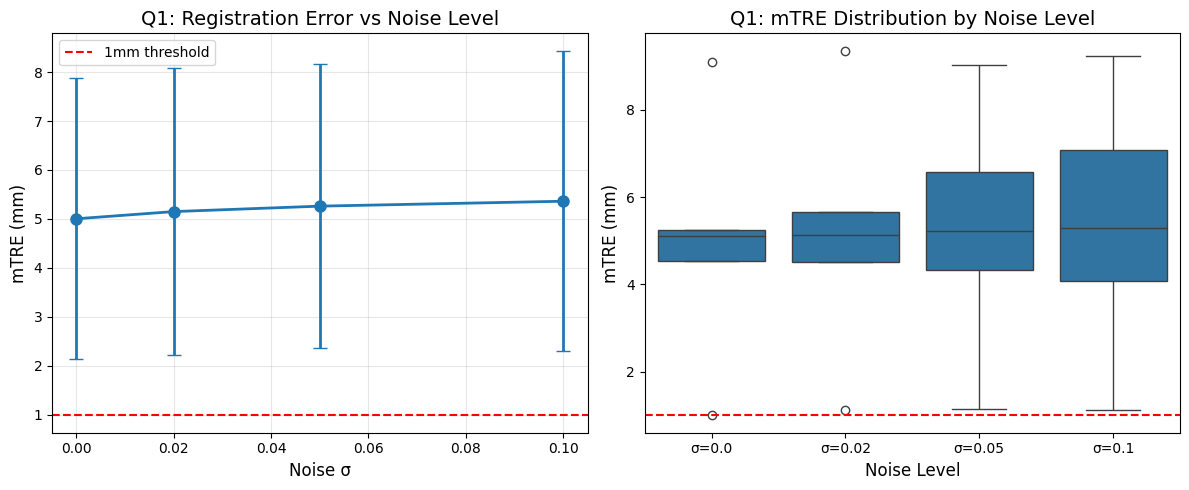

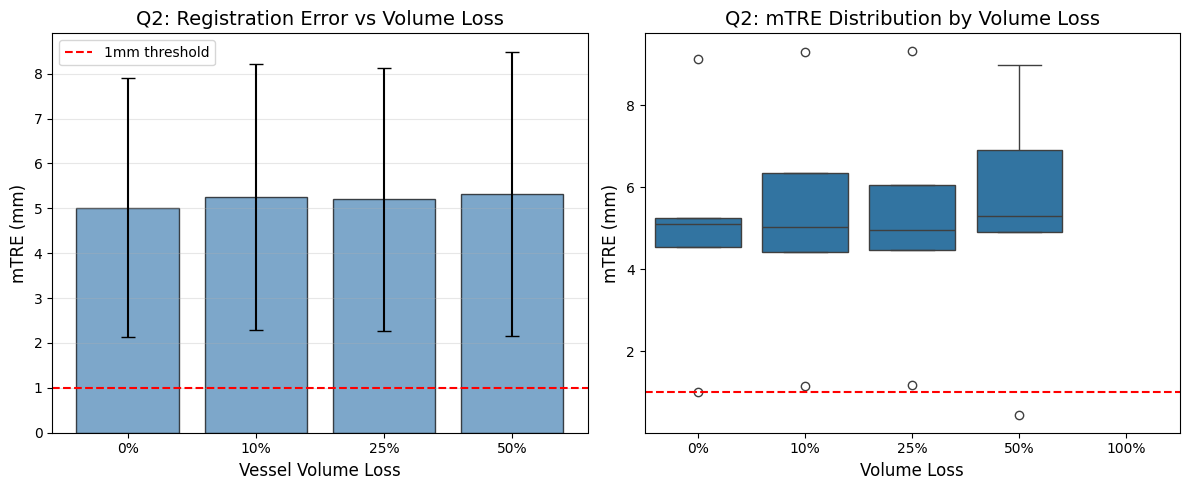

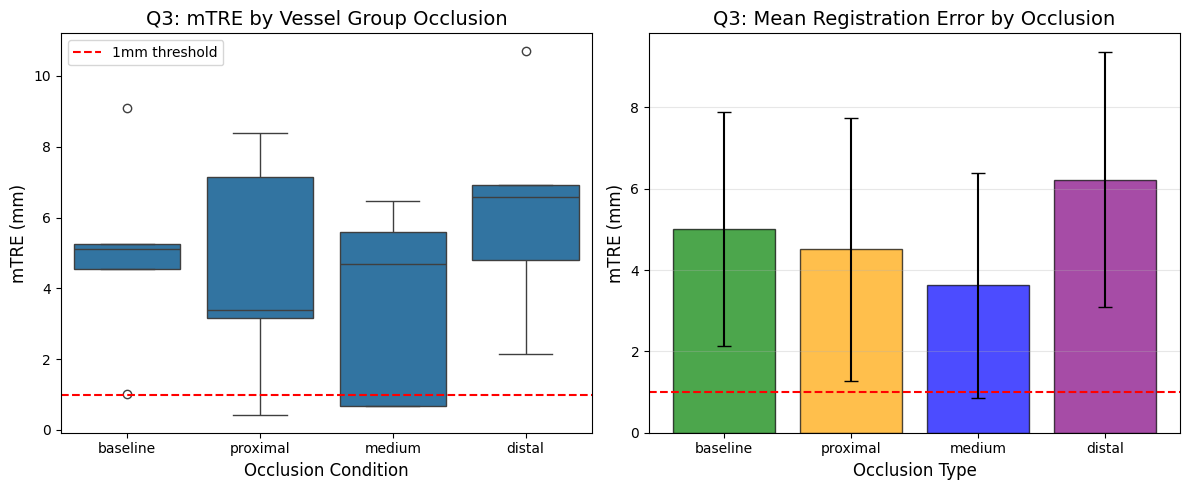

In [ ]:
# Generate visualizations
plot_all_results(results_df, OUTPUT_DIR)

In [ ]:
# Statistical analysis
analyzer = StatisticalAnalyzer(results_df)
report = analyzer.generate_report()
print(report)

# Save report
with open(OUTPUT_DIR / 'statistical_report.txt', 'w') as f:
    f.write(report)
print(f"\nReport saved to {OUTPUT_DIR / 'statistical_report.txt'}")

STATISTICAL ANALYSIS REPORT

Q1: NOISE DEGRADATION TOLERANCE

Summary by noise level:
  σ=0.00: mean=5.00mm, std=2.87mm, median=5.11mm
  σ=0.02: mean=5.15mm, std=2.94mm, median=5.13mm
  σ=0.05: mean=5.26mm, std=2.90mm, median=5.22mm
  σ=0.10: mean=5.36mm, std=3.06mm, median=5.30mm

Paired comparisons (Wilcoxon, Holm-Bonferroni corrected):
  σ=0 vs σ=0.02: p=0.9375, median_diff=0.095mm
  σ=0 vs σ=0.05: p=1.0000, median_diff=0.104mm
  σ=0 vs σ=0.1: p=1.0000, median_diff=0.123mm

Q2: VESSEL VOLUME LOSS

Non-inferiority testing (margin = 1.0mm):
  Loss=0%: mean=5.01mm, 95% CI=[2.68, 7.42] → ✗ NOT non-inferior
  Loss=10%: mean=5.25mm, 95% CI=[2.96, 7.47] → ✗ NOT non-inferior
  Loss=25%: mean=5.20mm, 95% CI=[2.91, 7.48] → ✗ NOT non-inferior
  Loss=50%: mean=5.32mm, 95% CI=[2.72, 7.43] → ✗ NOT non-inferior

Q3: VESSEL GROUP OCCLUSION

Summary by occlusion type:
  baseline: mean=5.00mm, std=2.87mm
  distal: mean=6.22mm, std=3.13mm
  medium: mean=3.62mm, std=2.76mm
  proximal: mean=4.50mm, std=

---
## 8. Quick Test (Single Patient)

Running quick GPU test...
Loaded patient 001: shape=(142, 164, 122)
GT pose: rot=[-1.2545989  4.507143   2.3199394], trans=[ 0.98658484 -3.4398136  -3.440055  ]


Registering:   0%|          | 0/100 [00:00<?, ?it/s]


Registration completed in 1.92s
Best NCC: 0.9995
Predicted pose: [-1.1573026  4.4822717  2.308348   0.8910319 -3.5038247 -4.4146557]
GT pose: [-1.2545989   4.507143    2.3199394   0.98658484 -3.4398136  -3.440055  ]
Pose error: [ 0.09729624 -0.02487135 -0.01159143 -0.09555292 -0.0640111  -0.9746008 ]


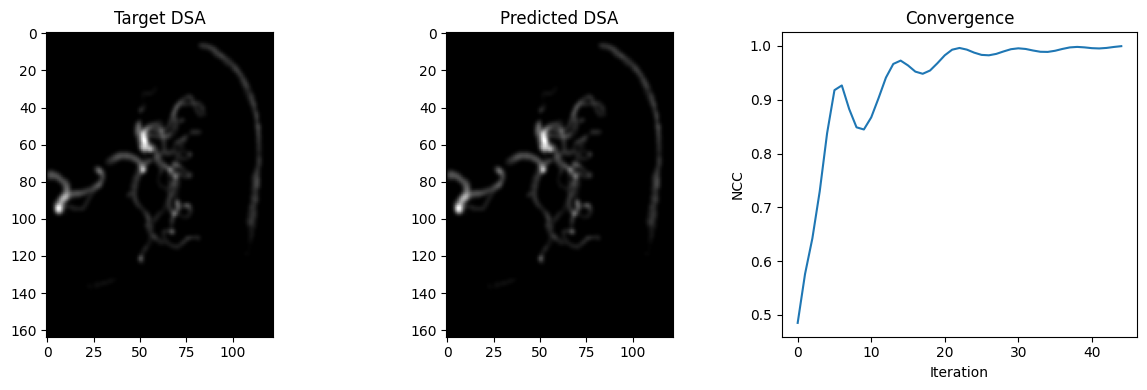

RegistrationResult(pred_pose=array([-1.1573026,  4.4822717,  2.308348 ,  0.8910319, -3.5038247,
       -4.4146557], dtype=float32), pred_image=array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32), best_score=0.99954754114151, score_history=[0.485329270362854, 0.5761693716049194, 0.6425959467887878, 0.7301104664802551, 0.8377739787101746, 0.9178241491317749, 0.9265607595443726, 0.8827961087226868, 0.848755955696106, 0.8447306752204895, 0.8672094941139221, 0.9031297564506531, 0.9411308765411377, 0.9665248394012451, 0.9727291464805603, 0.9637811779975891, 0.9522396922111511, 0.9482397437095642, 0.9543326497077942, 0.9678643345832825, 0.9825813174247742, 0.9929860234260559, 0.9962101578712463, 0.9931387901306152, 0.9875292778015137, 0.983342170715332, 0.982576310634613, 0.9851955771446228, 

In [ ]:
# =============================================================================
# Quick Test: Single patient, single condition
# Use this to verify GPU acceleration is working
# =============================================================================

def quick_test():
    """Run a quick test with one patient."""
    print("Running quick GPU test...")

    # Load one patient
    patient_data = load_patient_data('001', downsample_factor=2)
    print(f"Loaded patient 001: shape={patient_data['shape']}")

    # Prepare data
    healthy_labels = get_healthy_hemisphere(patient_data['labels'])
    binary_mask = create_binary_mask(healthy_labels)
    spacing = patient_data['spacing']

    # Create projector
    volume_tensor = torch.tensor(binary_mask, dtype=torch.float32, device=device)
    projector = DifferentiableProjector(volume_tensor, spacing=spacing, proj_axis=0)

    # Generate GT pose
    np.random.seed(42)
    gt_pose = np.concatenate([
        np.random.uniform(-5, 5, 3),  # rotation
        np.random.uniform(-5, 5, 3)   # translation
    ]).astype(np.float32)
    print(f"GT pose: rot={gt_pose[:3]}, trans={gt_pose[3:]}")

    # Render target
    with torch.no_grad():
        gt_pose_tensor = torch.tensor(gt_pose, dtype=torch.float32, device=device)
        target_dsa = projector(gt_pose_tensor)

    # Time the registration
    import time
    start = time.time()

    config = RegistrationConfig(n_iters=100, verbose=True)
    result = register_gpu(projector, target_dsa, config=config)

    elapsed = time.time() - start

    print(f"\nRegistration completed in {elapsed:.2f}s")
    print(f"Best NCC: {result.best_score:.4f}")
    print(f"Predicted pose: {result.pred_pose}")
    print(f"GT pose: {gt_pose}")
    print(f"Pose error: {result.pred_pose - gt_pose}")

    # Visualize
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(target_dsa.cpu().numpy(), cmap='gray')
    axes[0].set_title('Target DSA')
    axes[1].imshow(result.pred_image, cmap='gray')
    axes[1].set_title('Predicted DSA')
    axes[2].plot(result.score_history)
    axes[2].set_xlabel('Iteration')
    axes[2].set_ylabel('NCC')
    axes[2].set_title('Convergence')
    plt.tight_layout()
    plt.show()

    return result

# Uncomment to run quick test
quick_test()

---
## Notes and Recommendations

### Speed Comparison
- **CPU (scipy)**: ~15-20 seconds per registration
- **GPU (PyTorch)**: ~1-3 seconds per registration (5-10x speedup)

### Statistical Power
With 3 patients × 5 trials = 15 samples per condition:
- Wilcoxon signed-rank test has ~80% power to detect medium effects (d=0.5)
- Bootstrap CI provides robust uncertainty estimates

### Limitations
1. **Not true DiffPose**: Uses MIP projection, not physics-based X-ray simulation
2. **Binary masks**: Registration may be less robust than with full CT contrast
3. **No CNN pretraining**: Starts from identity pose, may get stuck in local minima

### Future Improvements
1. Multi-start registration to escape local minima
2. Coarse-to-fine pyramid with volume downsampling
3. Use full CTA with DiffDRR for realistic X-ray simulation